# Neural Networks
ML LAB 4 

**Yasir Ahmad**  
22MIA1064

### Activation Functions
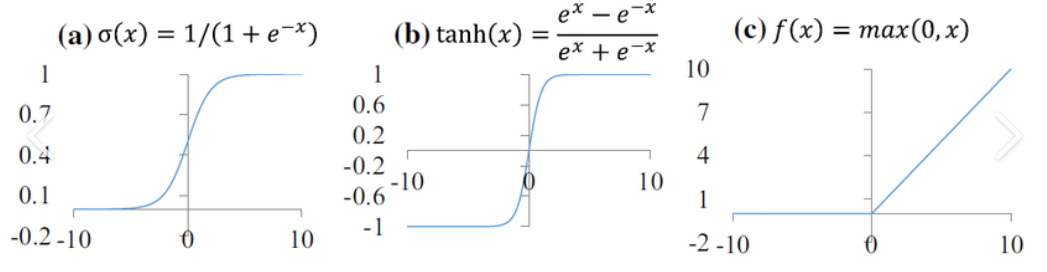

## Setup
generate single output dataset

In [14]:
import numpy as np # type: ignore
import tensorflow as tf # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from sklearn.datasets import make_classification, make_moons # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Function to generate linear and non-linear datasets
def generate_datasets():
    # Linear Dataset
    X_linear, y_linear = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, 
                                             n_clusters_per_class=1, n_classes=2, random_state=42)
    
    # Non-linear Dataset (moons)
    X_nonlinear, y_nonlinear = make_moons(n_samples=1000, noise=0.2, random_state=42)
    
    return (X_linear, y_linear), (X_nonlinear, y_nonlinear)

# Plotting function to visualize datasets
def plot_datasets(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(title)
    plt.show()


## Perceptron

In [15]:
def build_perceptron(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(1, activation=activation, input_shape=(2,), use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  ## optimizer SDG, but slow to converge and not always the best
    
    return model


In [16]:
#viz model
from tensorflow.keras.utils import plot_model #type: ignore

def vis_model(model):
    plot_model(model, to_file="mlp_architecture.png", show_shapes=True, show_layer_names=True, expand_nested=True)
    
    # Display the image if running in a notebook
    from IPython.display import Image # type: ignore
    display(Image(filename='mlp_architecture.png'))


In [17]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_perceptron(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=5, batch_size=1, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    model.summary()
    return [(activation, use_bias, accuracy),(weights, bias)]


### Main code

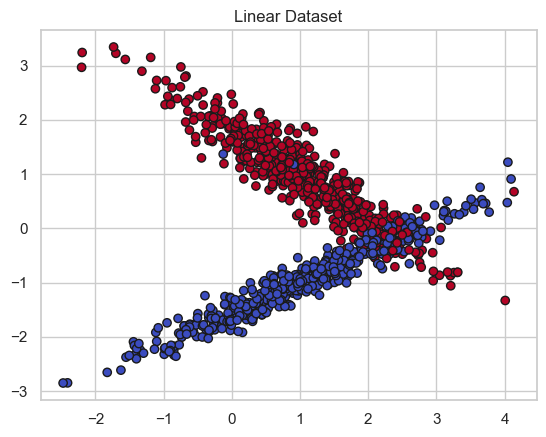

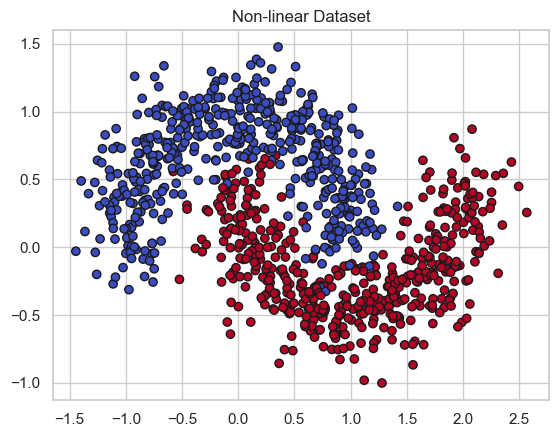

Linear Dataset Results:
Epoch 1/5
1000/1000 [==============================] - 4s 2ms/step - loss: 0.4162 - accuracy: 0.8560
Epoch 2/5
1000/1000 [==============================] - 2s 2ms/step - loss: 0.3224 - accuracy: 0.8940
Epoch 3/5
1000/1000 [==============================] - 2s 2ms/step - loss: 0.2869 - accuracy: 0.8960
Epoch 4/5
1000/1000 [==============================] - 3s 3ms/step - loss: 0.2703 - accuracy: 0.8970
Epoch 5/5
1000/1000 [==============================] - 3s 3ms/step - loss: 0.2615 - accuracy: 0.8970
Weights: [[0.07578743]
 [2.4613118 ]]
Bias: [-0.07879344]
Activation: sigmoid, Use Bias: True, Accuracy: 0.90
Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 1)                 3         
                                                                 
Total params: 3 (12.00 Byte)
Trainable params: 3 (12.00 Byte)
Non-trainabl

In [18]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

#For metrics
metrics = {"Linear":[],"Non Linear":[]}
params = {"Linear":[],"Non Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)

# Running experiments for non-linear dataset
print("\nNon-linear Dataset Results:")
for activation in activations:
    nl1,np1 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=True)
    nl2,np2 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=False)
    metrics["Non Linear"].append(nl1)
    metrics["Non Linear"].append(nl2)
    params["Non Linear"].append(np1)
    params["Non Linear"].append(np2)


In [19]:
params['Linear']

[(array([[0.07578743],
         [2.4613118 ]], dtype=float32),
  array([-0.07879344], dtype=float32)),
 (array([[-7.5468712e-04],
         [ 1.4250016e+00]], dtype=float32),
  None),
 (array([[0.37474734],
         [1.0873877 ]], dtype=float32),
  array([0.03192871], dtype=float32)),
 (array([[0.36582652],
         [1.1897573 ]], dtype=float32),
  None),
 (array([[0.09725628],
         [0.8916099 ]], dtype=float32),
  array([0.37893176], dtype=float32)),
 (array([[0.22800806],
         [0.6308847 ]], dtype=float32),
  None)]

### Metrics

In [20]:
metrics

{'Linear': [('sigmoid', True, 0.8960000276565552),
  ('sigmoid', False, 0.8999999761581421),
  ('tanh', True, 0.8849999904632568),
  ('tanh', False, 0.8849999904632568),
  ('relu', True, 0.890999972820282),
  ('relu', False, 0.8730000257492065)],
 'Non Linear': [('sigmoid', True, 0.8700000047683716),
  ('sigmoid', False, 0.8489999771118164),
  ('tanh', True, 0.49900001287460327),
  ('tanh', False, 0.5),
  ('relu', True, 0.8579999804496765),
  ('relu', False, 0.21400000154972076)]}

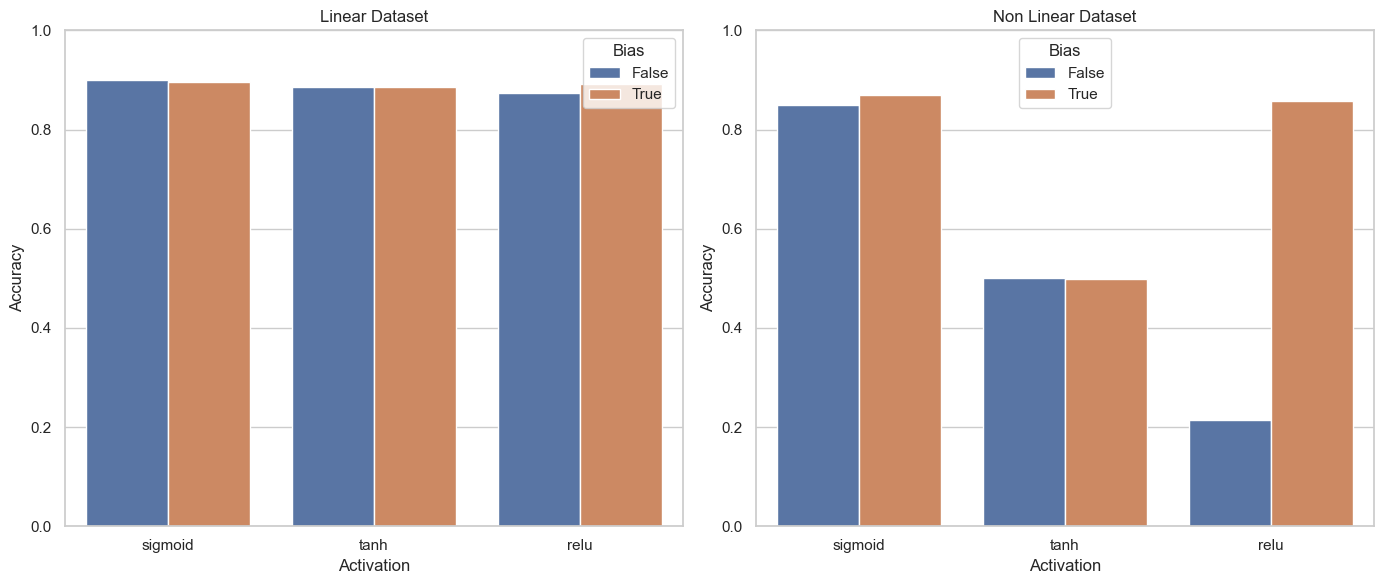

In [21]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'], ax=axes[0])
axes[0].set_title('Linear Dataset')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Bias')

# Plot for Non Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Non Linear'], ax=axes[1])
axes[1].set_title('Non Linear Dataset')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Backpropagation

In [22]:
def build_perceptron(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(1, activation=activation, input_shape=(2,), use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_perceptron(activation=activation, use_bias=use_bias)
    model.fit(X, y, epochs=10, batch_size=1000, verbose=1)
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    model.summary()
    return (activation,use_bias,accuracy)

### Main Code

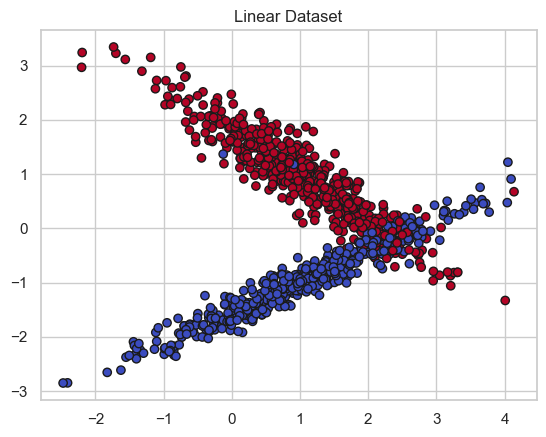

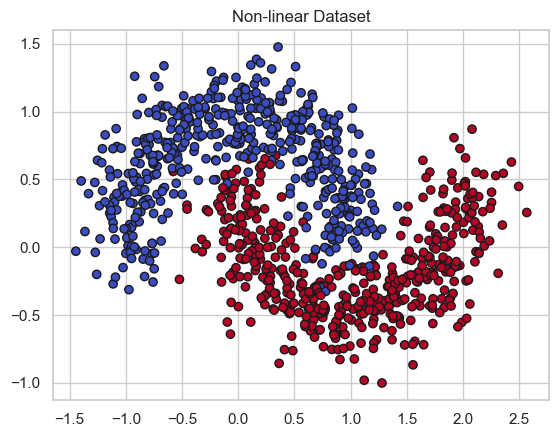

Linear Dataset Results:
Epoch 1/10
1/1 [==============================] - 1s 1s/step - loss: 0.6352 - accuracy: 0.7730
Epoch 2/10
1/1 [==============================] - 0s 12ms/step - loss: 0.6347 - accuracy: 0.7760
Epoch 3/10
1/1 [==============================] - 0s 15ms/step - loss: 0.6342 - accuracy: 0.7790
Epoch 4/10
1/1 [==============================] - 0s 68ms/step - loss: 0.6337 - accuracy: 0.7810
Epoch 5/10
1/1 [==============================] - 0s 14ms/step - loss: 0.6332 - accuracy: 0.7850
Epoch 6/10
1/1 [==============================] - 0s 13ms/step - loss: 0.6327 - accuracy: 0.7880
Epoch 7/10
1/1 [==============================] - 0s 14ms/step - loss: 0.6322 - accuracy: 0.7910
Epoch 8/10
1/1 [==============================] - 0s 14ms/step - loss: 0.6317 - accuracy: 0.7930
Epoch 9/10
1/1 [==============================] - 0s 28ms/step - loss: 0.6312 - accuracy: 0.7960
Epoch 10/10
1/1 [==============================] - 0s 15ms/step - loss: 0.6307 - accuracy: 0.7990
Activat

In [23]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

#For metrics
metrics = {"Linear":[],"Non Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)

# Running experiments for non-linear dataset
print("\nNon-linear Dataset Results:")
for activation in activations:
    nl1 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=True)
    nl2 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=False)
    metrics["Non Linear"].append(nl1)
    metrics["Non Linear"].append(nl2)


### Metrics

In [24]:
metrics

{'Linear': [('sigmoid', True, 0.8029999732971191),
  ('sigmoid', False, 0.7020000219345093),
  ('tanh', True, 0.8740000128746033),
  ('tanh', False, 0.08900000154972076),
  ('relu', True, 0.21799999475479126),
  ('relu', False, 0.8529999852180481)],
 'Non Linear': [('sigmoid', True, 0.6449999809265137),
  ('sigmoid', False, 0.42100000381469727),
  ('tanh', True, 0.43799999356269836),
  ('tanh', False, 0.1770000010728836),
  ('relu', True, 0.42800000309944153),
  ('relu', False, 0.7400000095367432)]}

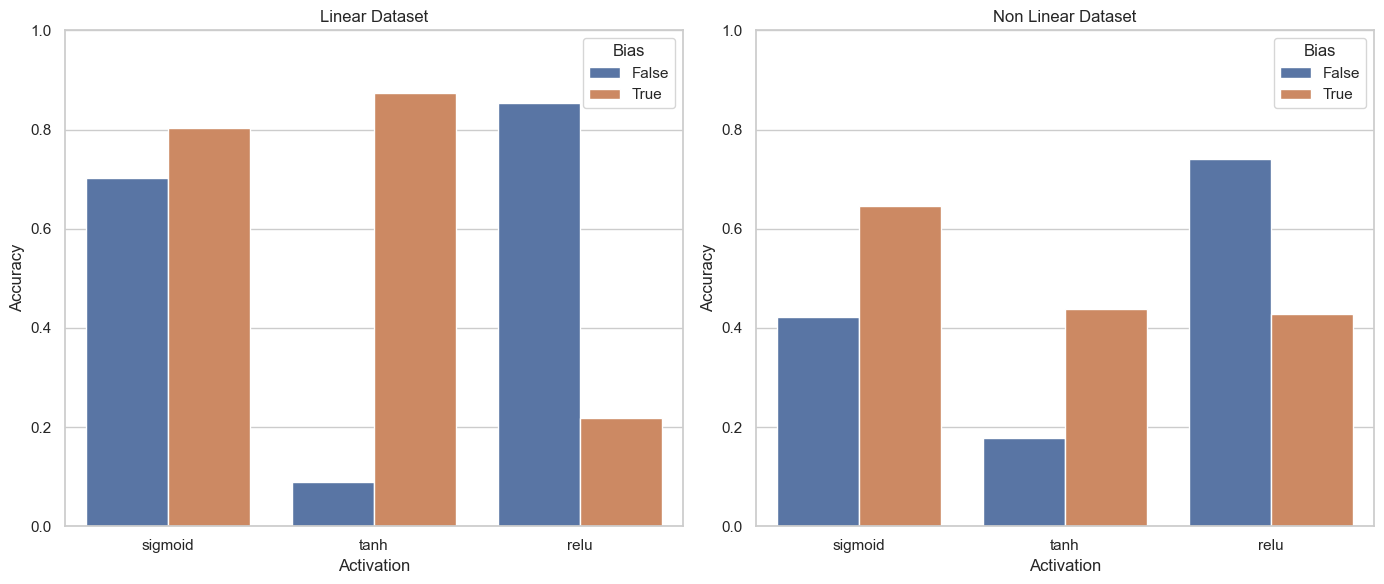

In [25]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'], ax=axes[0])
axes[0].set_title('Linear Dataset')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Bias')

# Plot for Non Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Non Linear'], ax=axes[1])
axes[1].set_title('Non Linear Dataset')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Multilayer perceptron

In [26]:
def build_mlp(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(2, activation=activation, input_shape=(2,), use_bias=use_bias),
        Dense(3, activation=activation, use_bias=use_bias),
        Dense(1, activation=activation, use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model


In [27]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_mlp(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=10, batch_size=1, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    model.summary()
    return [(activation, use_bias, accuracy),(weights, bias)]


### Main Code

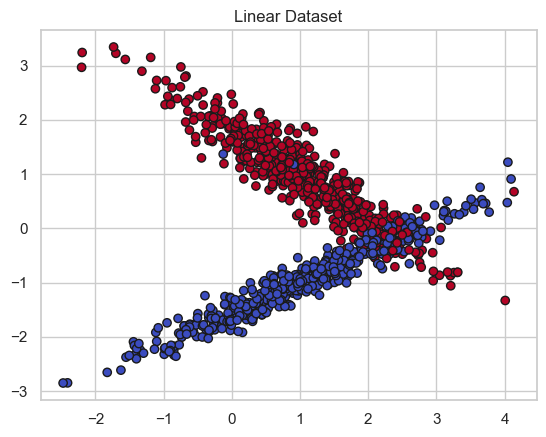

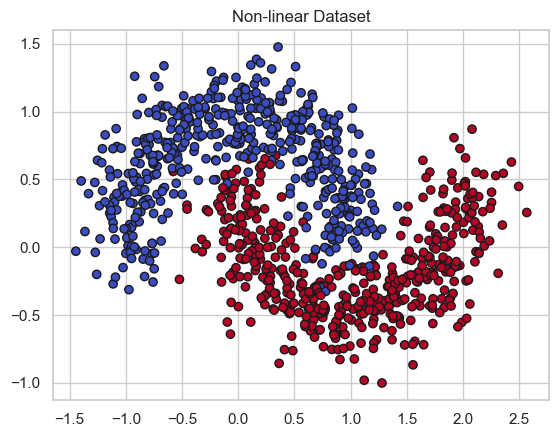

Linear Dataset Results:
Epoch 1/10
1000/1000 [==============================] - 6s 4ms/step - loss: 0.6967 - accuracy: 0.5260
Epoch 2/10
1000/1000 [==============================] - 5s 5ms/step - loss: 0.6582 - accuracy: 0.8590
Epoch 3/10
1000/1000 [==============================] - 4s 4ms/step - loss: 0.6014 - accuracy: 0.8950
Epoch 4/10
1000/1000 [==============================] - 4s 4ms/step - loss: 0.5228 - accuracy: 0.8920
Epoch 5/10
1000/1000 [==============================] - 4s 4ms/step - loss: 0.4401 - accuracy: 0.8980
Epoch 6/10
1000/1000 [==============================] - 6s 6ms/step - loss: 0.3741 - accuracy: 0.8980
Epoch 7/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.3297 - accuracy: 0.8970
Epoch 8/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.3026 - accuracy: 0.8990
Epoch 9/10
1000/1000 [==============================] - 4s 4ms/step - loss: 0.2853 - accuracy: 0.9000
Epoch 10/10
1000/1000 [==============================] - 6

In [28]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

#For metrics
metrics = {"Linear":[],"Non Linear":[]}
params = {"Linear":[],"Non Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)

# Running experiments for non-linear dataset
print("\nNon-linear Dataset Results:")
for activation in activations:
    nl1,np1 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=True)
    nl2,np2 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=False)
    metrics["Non Linear"].append(nl1)
    metrics["Non Linear"].append(nl2)
    params["Non Linear"].append(np1)
    params["Non Linear"].append(np2)


In [29]:
metrics

{'Linear': [('sigmoid', True, 0.8999999761581421),
  ('sigmoid', False, 0.8989999890327454),
  ('tanh', True, 0.5009999871253967),
  ('tanh', False, 0.8880000114440918),
  ('relu', True, 0.8740000128746033),
  ('relu', False, 0.5009999871253967)],
 'Non Linear': [('sigmoid', True, 0.8679999709129333),
  ('sigmoid', False, 0.859000027179718),
  ('tanh', True, 0.8679999709129333),
  ('tanh', False, 0.7630000114440918),
  ('relu', True, 0.8550000190734863),
  ('relu', False, 0.5)]}

In [30]:
params

{'Linear': [(array([[-0.32167345,  0.86019677],
          [-4.0740824 , -2.861789  ]], dtype=float32),
   array([-0.31443805, -0.8317341 ], dtype=float32)),
  (array([[ 0.4923322 ,  0.19221981],
          [-3.6917646 ,  3.9204895 ]], dtype=float32),
   None),
  (array([[ 0.09826167,  0.45819074],
          [-0.03626601,  0.55107325]], dtype=float32),
   array([0.15259871, 0.10471924], dtype=float32)),
  (array([[-0.47510037, -0.49436677],
          [-0.921736  ,  1.08058   ]], dtype=float32),
   None),
  (array([[0.468069  , 0.56899273],
          [0.22852997, 1.5824665 ]], dtype=float32),
   array([-0.3857085 , -0.01917788], dtype=float32)),
  (array([[0.22809994, 1.2205402 ],
          [0.60713243, 1.1995481 ]], dtype=float32),
   None)],
 'Non Linear': [(array([[-0.92016166,  1.3765758 ],
          [ 3.8899436 , -3.748825  ]], dtype=float32),
   array([-0.29960775, -0.26396686], dtype=float32)),
  (array([[ 1.2649887,  1.3240962],
          [-4.405025 , -4.4105124]], dtype=float32),

### Metrics

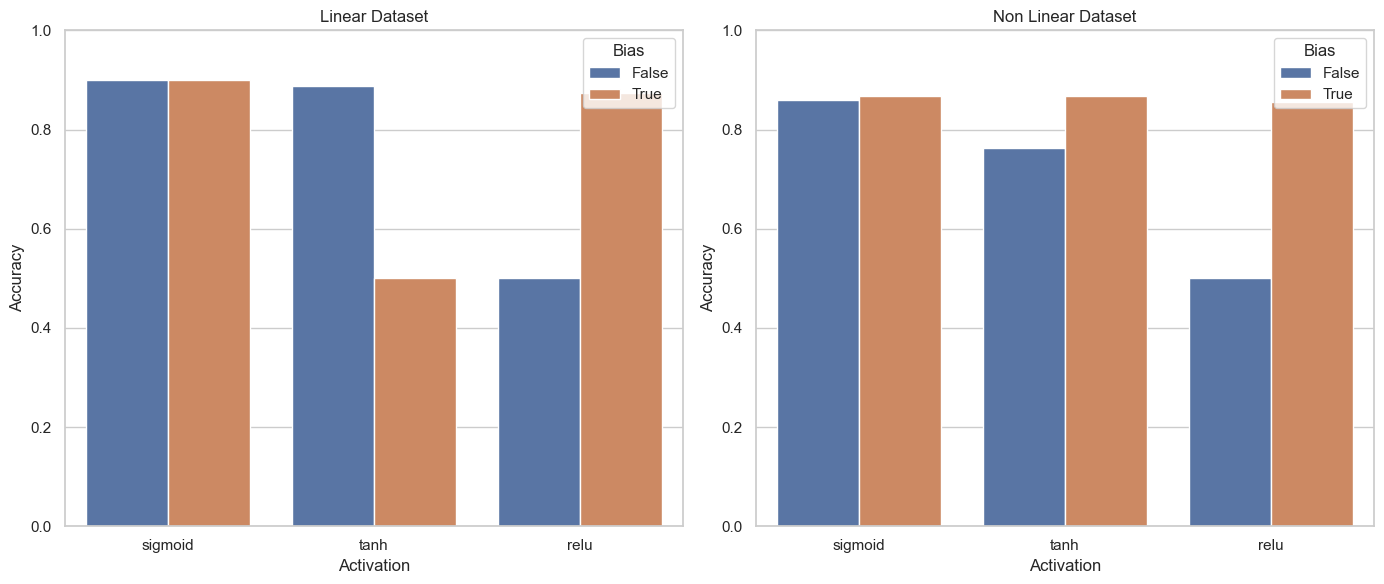

In [31]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'], ax=axes[0])
axes[0].set_title('Linear Dataset')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Bias')

# Plot for Non Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Non Linear'], ax=axes[1])
axes[1].set_title('Non Linear Dataset')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Multiple outputs MLP

In [32]:
import numpy as np # type: ignore
import tensorflow as tf # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from sklearn.datasets import make_classification, make_moons # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Function to generate linear and non-linear datasets
def generate_datasets():
    # Linear Dataset
    X_linear, y_linear = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, 
                                             n_clusters_per_class=1, n_classes=3, random_state=42)
    
        
    return (X_linear, y_linear), (X_nonlinear, y_nonlinear)

# Plotting function to visualize datasets
def plot_datasets(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(title)
    plt.show()


In [33]:
def build_mlp(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(2, activation=activation, input_shape=(2,), use_bias=use_bias),
        Dense(3, activation=activation, use_bias=use_bias),
        Dense(3, activation="softmax", use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model


In [34]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_mlp(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=10, batch_size=1, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    model.summary()
    return [(activation, use_bias, accuracy),(weights, bias)]


C:\Users\YasirAhmd\AppData\Local\Temp\ipykernel_7616\276242794.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')


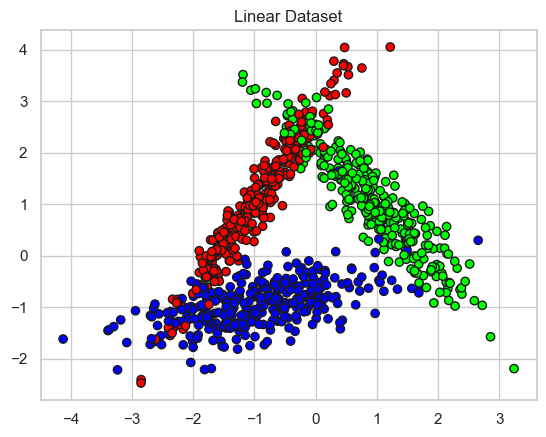

Linear Dataset Results:
Epoch 1/10
1000/1000 [==============================] - 7s 4ms/step - loss: 1.1250 - accuracy: 0.3520
Epoch 2/10
1000/1000 [==============================] - 3s 3ms/step - loss: 1.0456 - accuracy: 0.5810
Epoch 3/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.9815 - accuracy: 0.7140
Epoch 4/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.8991 - accuracy: 0.7830
Epoch 5/10
1000/1000 [==============================] - 4s 4ms/step - loss: 0.8064 - accuracy: 0.7670
Epoch 6/10
1000/1000 [==============================] - 4s 4ms/step - loss: 0.7159 - accuracy: 0.7780
Epoch 7/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.6387 - accuracy: 0.8290
Epoch 8/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.5752 - accuracy: 0.8650
Epoch 9/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.5231 - accuracy: 0.8650
Epoch 10/10
1000/1000 [==============================] - 2

In [35]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

# Convert target variable to one-hot encoding
y_linear = tf.keras.utils.to_categorical(y_linear)

#For metrics
metrics = {"Linear":[]}
params = {"Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)



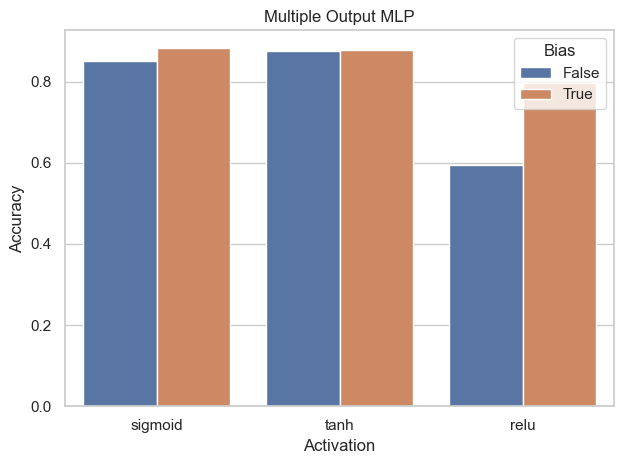

In [36]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
#fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear Multiple Output dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'])
plt.title('Multiple Output MLP')
plt.legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Multiple Output Backprop

In [37]:
def build_mlp(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(2, activation=activation, input_shape=(2,), use_bias=use_bias),
        Dense(3, activation=activation, use_bias=use_bias),
        Dense(3, activation="softmax", use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model


In [38]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_mlp(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=10, batch_size=1000, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    model.summary()
    return [(activation, use_bias, accuracy),(weights, bias)]


C:\Users\YasirAhmd\AppData\Local\Temp\ipykernel_7616\276242794.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')


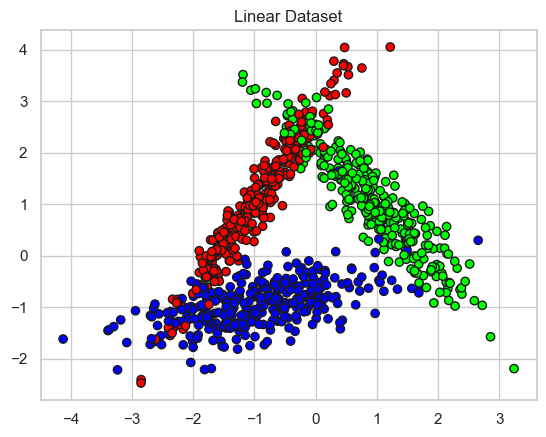

Linear Dataset Results:
Epoch 1/10
1/1 [==============================] - 4s 4s/step - loss: 1.1325 - accuracy: 0.3320
Epoch 2/10
1/1 [==============================] - 0s 16ms/step - loss: 1.1314 - accuracy: 0.3320
Epoch 3/10
1/1 [==============================] - 0s 17ms/step - loss: 1.1303 - accuracy: 0.3320
Epoch 4/10
1/1 [==============================] - 0s 17ms/step - loss: 1.1293 - accuracy: 0.3320
Epoch 5/10
1/1 [==============================] - 0s 49ms/step - loss: 1.1282 - accuracy: 0.3320
Epoch 6/10
1/1 [==============================] - 0s 21ms/step - loss: 1.1271 - accuracy: 0.3320
Epoch 7/10
1/1 [==============================] - 0s 22ms/step - loss: 1.1261 - accuracy: 0.3320
Epoch 8/10
1/1 [==============================] - 0s 19ms/step - loss: 1.1251 - accuracy: 0.3320
Epoch 9/10
1/1 [==============================] - 0s 22ms/step - loss: 1.1240 - accuracy: 0.3320
Epoch 10/10
1/1 [==============================] - 0s 20ms/step - loss: 1.1230 - accuracy: 0.3320
Weights

In [39]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

# Convert target variable to one-hot encoding
y_linear = tf.keras.utils.to_categorical(y_linear)

#For metrics
metrics = {"Linear":[]}
params = {"Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)



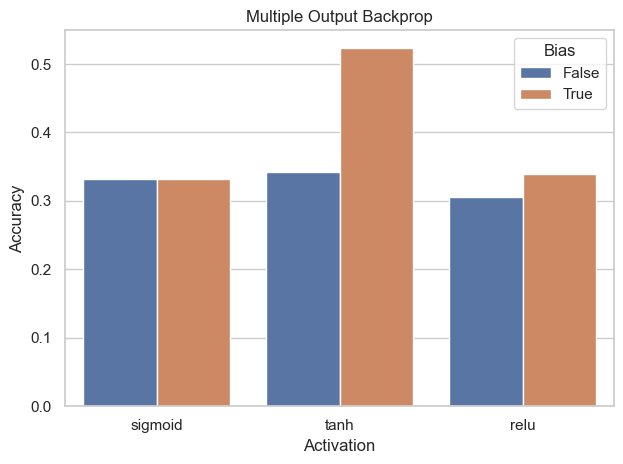

In [40]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
#fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear Multiple Output dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'])
plt.title('Multiple Output Backprop')
plt.legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()
